In [ ]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

In [ ]:
dag_c4: dict = torch.load(os.path.join(config["result_path"], "circuits/dag_olmoe_c4.pt"), map_location='cpu')
dag_code: dict = torch.load(os.path.join(config["result_path"], "circuits/dag_olmoe_code.pt"), map_location='cpu')
dag_math: dict = torch.load(os.path.join(config["result_path"], "circuits/dag_olmoe_math.pt"), map_location='cpu')

In [ ]:
from experiments.circuits.helper import thresholding_routing_graph, get_thresholds

t_c4: float = get_thresholds(dag_c4, "AARV", [0.99])[0.99]
dag_c4: ig.Graph = thresholding_routing_graph(dag_c4, "AARV", t_c4)

t_code: float = get_thresholds(dag_code, "AARV", [0.99])[0.99]
dag_code: ig.Graph = thresholding_routing_graph(dag_code, "AARV", t_code)

t_math: float = get_thresholds(dag_math, "AARV", [0.99])[0.99]
dag_math: ig.Graph = thresholding_routing_graph(dag_math, "AARV", t_math)

ModuleNotFoundError: No module named 'helper'

In [ ]:
A_c4 = np.array(dag_c4.get_adjacency(attribute="weight").data, dtype=float)
A_code = np.array(dag_code.get_adjacency(attribute="weight").data, dtype=float)
A_math = np.array(dag_math.get_adjacency(attribute="weight").data, dtype=float)

In [ ]:
U_c4, S_c4, Vt_c4 = np.linalg.svd(A_c4, full_matrices=False)
U_code, S_code, Vt_code = np.linalg.svd(A_code, full_matrices=False)
U_math, S_math, Vt_math = np.linalg.svd(A_math, full_matrices=False)

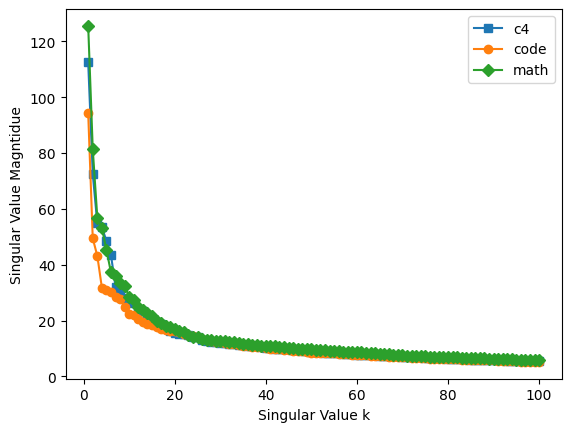

In [ ]:
k = 100
x = np.arange(start=1, stop=k+1, step=1)
plt.plot(x, S_c4[:k], label="c4", marker='s')
plt.plot(x, S_code[:k], label="code", marker='o')
plt.plot(x, S_math[:k], label="math", marker='D')

plt.xlabel("Singular Value k")
plt.ylabel("Singular Value Magntidue")
plt.legend()
plt.show()

In [ ]:
# make a sweep: threshold x subspace_similarity
# i don't even know whether the subspace similarity is a good metric ... 

Uc4   = U_c4[:, :k]
Ucode = U_code[:, :k]
Umath = U_math[:, :k]

def subspace_similarity(U1, U2):
    M = U1.T @ U2
    s = np.linalg.svd(M, compute_uv=False)

    angles = np.arccos(np.clip(s, -1.0, 1.0))
    similarity = s.mean()

    return similarity, s, angles

sim_c4_code, s_c4_code, ang_c4_code = subspace_similarity(Uc4, Ucode)
sim_c4_math, s_c4_math, ang_c4_math = subspace_similarity(Uc4, Umath)
sim_code_math, s_code_math, ang_code_math = subspace_similarity(Ucode, Umath)

print("c4 ↔ code:", sim_c4_code)
print("c4 ↔ math:", sim_c4_math)
print("code ↔ math:", sim_code_math)

c4 ↔ code: 0.6291010278206827
c4 ↔ math: 0.7397075245993535
code ↔ math: 0.6084693181868148


In [8]:
!ls

circuits	   dataset	  modified_models_backup  README.md
config.yaml	   experiments	  MoEs			  results
customized_models  models_backup  papers		  tools
